In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=True)

counts = scarf.cytebase.connect("scarf_docs").download(
    'tenx_5K_pbmc_rnaseq/data.h5',
    destination='scarf_datasets',
)[0]

store = counts.with_name('data.zarr')
reader = scarf.CrH5Reader(str(counts))
scarf.CrToZarr(
    reader,
    zarr_loc=str(store),
).dump()

ds = scarf.DataStore(
    str(store),
    nthreads=4,
    min_features_per_cell=10,
)

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

Writing counts: 2 / 2 complete

Computing RNA initialization statistics: 1 / 1 complete

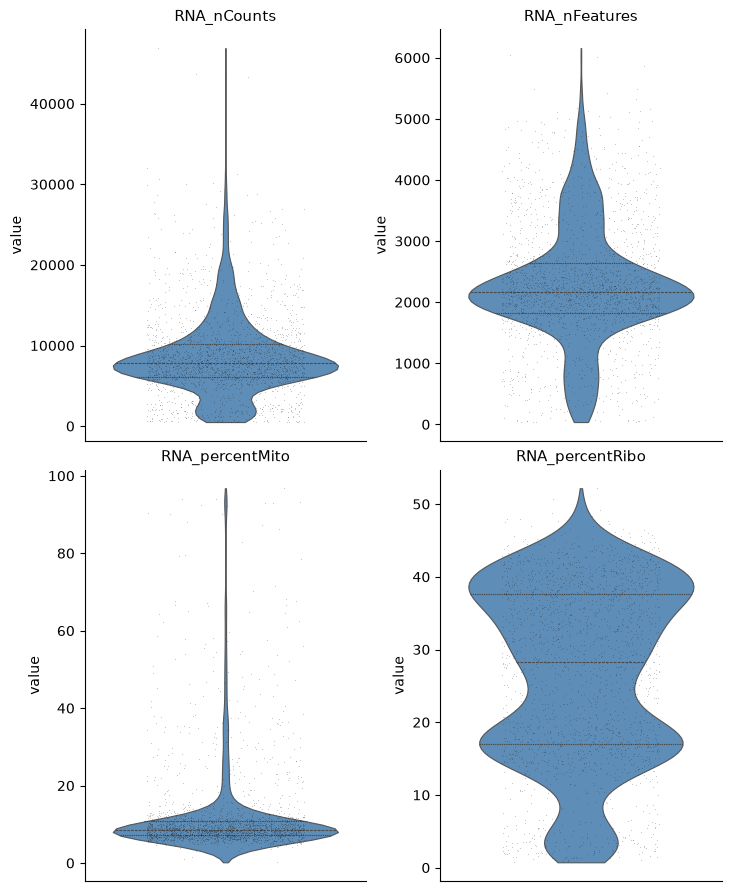

In [2]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
qc_cell_selection = ds.snapshot_cell_selection('I')
ds.plots.distribution(
    keys=qc_cols,
    cell_selection=qc_cell_selection,
    kind='violin',
    max_points=2000,
)

In [3]:
n_before = int(ds.cells.fetch_all('I').sum())
manual_selection = ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
)
manual_mask = np.asarray(ds.load_artifact(manual_selection)['values'][:], dtype=bool)
print(f'Cells in input selection: {n_before}')
print(f'Cells in filtered selection: {int(manual_mask.sum())}')
pd.DataFrame({key: ds.cells.fetch_all(key)[manual_mask] for key in qc_cols}).describe()

Cells in input selection: 5025
Cells in filtered selection: 3940


,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo
count,3940.000000,3940.000000,3940.000000,3940.000000
mean,8245.728934,2270.309898,8.575001,30.207449
std,2468.784922,541.559187,2.110144,10.202904
min,1057.000000,512.000000,0.188857,0.737101
25%,6562.000000,1922.000000,7.047202,20.122006
50%,7882.500000,2186.500000,8.364386,32.484297
75%,9606.750000,2527.000000,9.872131,38.770864
max,14992.000000,3930.000000,14.998783,52.181596


In [4]:
automatic_selection = ds.auto_filter_cells(cell_selection=manual_selection)
automatic_mask = np.asarray(
    ds.load_artifact(automatic_selection)['values'][:],
    dtype=bool,
)
print(f'Cells after automatic refinement: {int(automatic_mask.sum())}')

Cells after automatic refinement: 3595


In [5]:
ds.cells.insert(
    "qc_sample",
    np.asarray(
        [f"sample_{index % 4}" for index in range(ds.cells.N)]
    ),
    overwrite=True,
)
n_before = int(ds.cells.fetch_all('I').sum())
sample_selection = ds.auto_filter_cells(
    attrs=qc_cols,
    sample_column="qc_sample",
    n_mads=3.0,
    min_cells_per_sample=20,
)
sample_mask = np.asarray(ds.load_artifact(sample_selection)['values'][:], dtype=bool)
print(f'Cells in input selection: {n_before}')
print(f'Cells after MAD filter: {int(sample_mask.sum())}')

Cells in input selection: 5025
Cells after MAD filter: 4324


In [6]:
feature_names = ds.RNA.feats.fetch_all("names").astype(str)
stress_features = ds.set_feature_selection(
    from_assay="RNA",
    mask=np.char.startswith(feature_names, "HSP"),
)
stress_percentage = ds.run_feature_percentage(
    manual_selection,
    stress_features,
)
stress_values = np.asarray(ds.load_artifact(stress_percentage)["values"][:])
pd.Series(stress_values, name="percent stress features").describe()

(RNA) Computing selected-feature percentages: 1 / 1 complete

count    3940.000000
mean        0.328357
std         0.130553
min         0.000000
25%         0.238518
50%         0.309843
75%         0.395623
max         1.531394
Name: percent stress features, dtype: float64

In [7]:
hvg_ref = ds.select_hvgs(
    manual_selection,
    min_cells=20,
    top_n=500,
    show_plot=False,
)
cell_selection = manual_selection
normalized = ds.run_normalization(cell_selection, hvg_ref)
pca = ds.run_pca(normalized, dims=15)
initialization = ds.build_embedding_initialization(pca)
ann_index = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
clusters = ds.run_leiden_clustering(graph, resolution=0.5)
doublets = ds.run_doublet_detection(
    clusters,
    graph,
)
umap = ds.run_umap(
    graph,
    initialization,
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
)

Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

...

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Writing simulated doublets: 1 / 1 complete

Computing RNA initialization statistics: 1 / 1 complete

Training UMAP: 100 / 100 complete

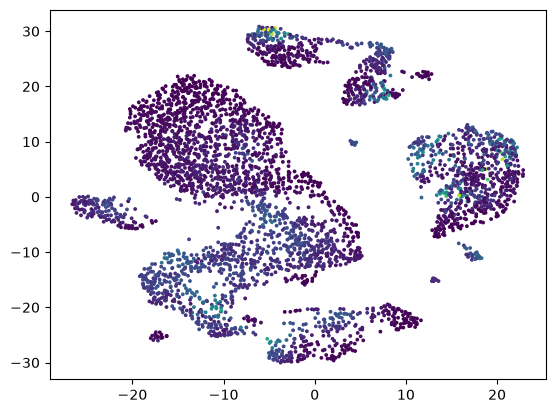

In [8]:
umap_values = np.asarray(ds.load_artifact(umap)['values'][:])
scores = np.asarray(ds.load_artifact(doublets)['values'][:])
plt.scatter(umap_values[:, 0], umap_values[:, 1], c=scores, s=3)

<Axes: ylabel='Frequency'>

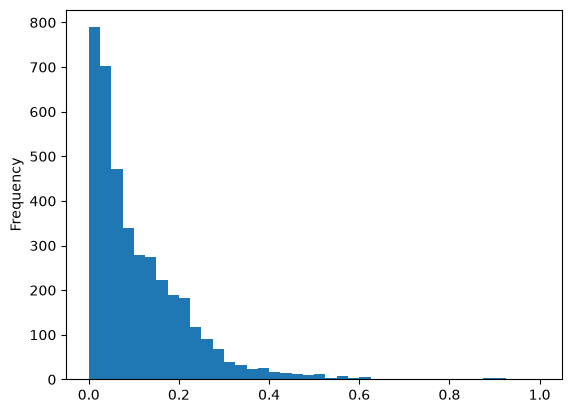

In [9]:
pd.Series(scores, name='doublet_score').plot(kind='hist', bins=40)

In [10]:
scores_series = pd.Series(scores, name='doublet_score')
print(scores_series.describe())
doublet_threshold = float(scores_series.quantile(0.95))
print(f'Doublet threshold (95th percentile): {doublet_threshold:.4f}')
print(f'Cells above threshold: {int((scores > doublet_threshold).sum())}')

count    3940.000000
mean        0.110904
std         0.110779
min         0.000000
25%         0.030497
50%         0.075340
75%         0.161276
max         1.000000
Name: doublet_score, dtype: float64
Doublet threshold (95th percentile): 0.3109
Cells above threshold: 197


In [11]:
doublet_filtered = ds.select_cells(
    doublets,
    high=doublet_threshold,
    keep_bounds=True,
)
int(np.asarray(ds.load_artifact(doublet_filtered)["values"][:]).sum())

3743